In [1]:
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np

In [26]:
ds = xr.open_dataset('/pscratch/sd/j/jiarongw/wave_data/NDBC/ww3_46042_2022.nc')
ds['hs_buoy'] = ds.spectral_density.integrate("frequency").compute() ** 0.5 * 4
ds

<xarray.Dataset> Size: 6MB
Dimensions:           (time: 2920, frequency: 47)
Coordinates:
  * time              (time) datetime64[ns] 23kB 2022-01-01 ... 2022-12-31T21...
  * frequency         (frequency) float64 376B 0.02 0.0325 ... 0.465 0.485
    longitude         float32 4B ...
    latitude          float32 4B ...
Data variables: (12/16)
    hs                (time) float32 12kB ...
    t0m1              (time) float32 12kB ...
    dir               (time) float32 12kB ...
    spr               (time) float32 12kB ...
    hs_p1             (time) float32 12kB ...
    tp_p1             (time) float32 12kB ...
    ...                ...
    r1                (time, frequency) float64 1MB ...
    r2                (time, frequency) float64 1MB ...
    alpha1            (time, frequency) float64 1MB ...
    alpha2            (time, frequency) float64 1MB ...
    spectral_density  (time, frequency) float64 1MB 0.0 0.0 0.0 ... 0.01 0.01
    hs_buoy           (time) float64 23kB 2.964 3.217 3.127 ... 2.677 2.985 3.17
Attributes: (12/103)
    WAVEWATCH_III_version_number:     7.00
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SCRIP SCRIPNC SHRD PR3 UQ...
    SIN4 namelist parameter BETAMAX:  1.75
    title:                            WAVEWATCH-III HINDCAST
    netcdf_version:                   4.5.2
    product_name:                     LOPS_WW3-GLOB-30M_202201.nc
    ...                               ...
    E3D:                              1
    I1P2SF:                           3
    I2P2SF:                           24
    start_date:                       2022-01-01 00:00:00
    stop_date:                        2022-01-31 21:00:00
    description:                      WW3 LOPS-GLOB-30M hindcast at buoy 4604...

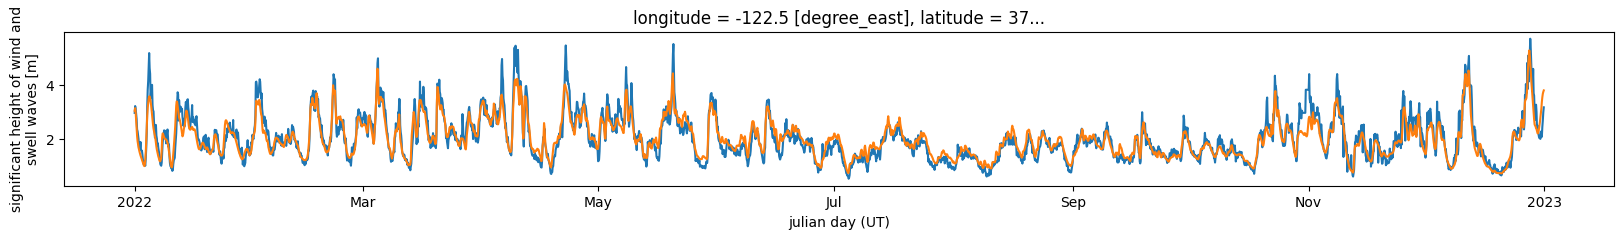

In [13]:
fig = plt.figure(figsize=[20,2])
ds.hs_buoy.plot()
ds.hs.plot()

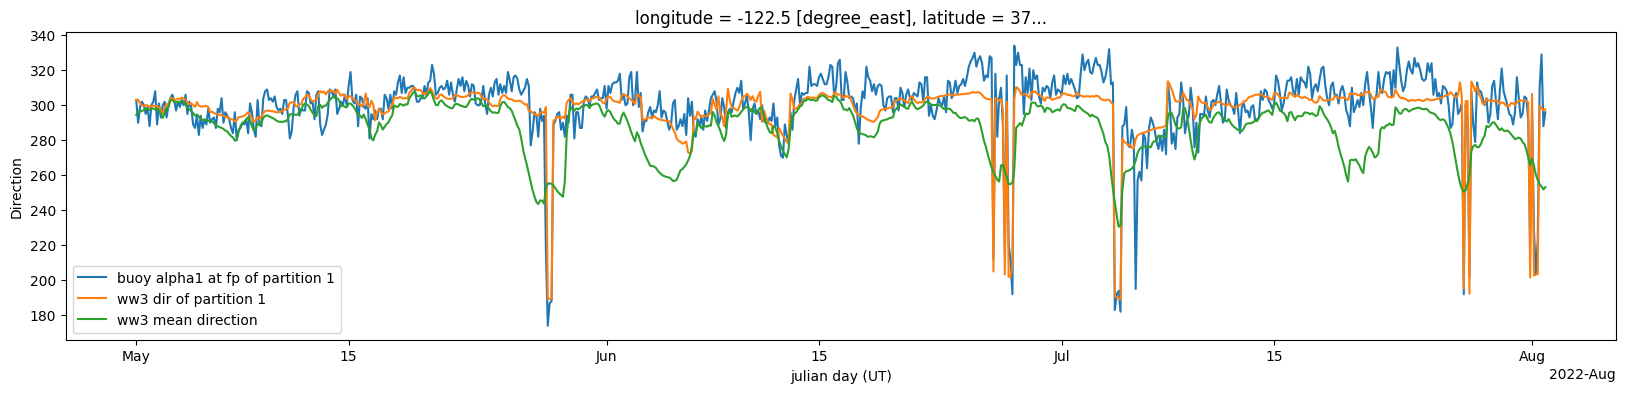

In [47]:
# Simple way of finding direction
fig = plt.figure(figsize=[20,4])
ds['dir_p1_buoy'] = ds.alpha1.sel(frequency=1/ds.tp_p1, method='nearest').compute()
ds.dir_p1_buoy.sel(time=slice('2022-05-01', '2022-08-01')).plot(label='buoy alpha1 at fp of partition 1')
ds.dir_p1.sel(time=slice('2022-05-01', '2022-08-01')).plot(label='ww3 dir of partition 1')
ds.dir.sel(time=slice('2022-05-01', '2022-08-01')).plot(label='ww3 mean direction')
plt.ylabel('Direction')
plt.legend()

In [39]:
rmse = np.mean((ds.dir_p1.values - ds.dir_p1_buoy.values) ** 2) ** 0.5
print(rmse)
rmse = np.mean((ds.dir_p1.values - ds.dir.values) ** 2) ** 0.5
print(rmse)
rmse = np.mean((ds.dir_p1_buoy.values - ds.dir.values) ** 2) ** 0.5
print(rmse)

13.540480119984636
18.808983
21.133016365853596


In [28]:
from roguewavespectrum import Spectrum

# WW3 stores directional info as (r, alpha) polar form; convert to Fourier coefficients
# a1 = r1 * cos(alpha1),  b1 = r1 * sin(alpha1)
# a2 = r2 * cos(2*alpha2), b2 = r2 * sin(2*alpha2)
alpha1_rad = np.deg2rad(ds.alpha1)
alpha2_rad = np.deg2rad(ds.alpha2)

ds_1d = xr.Dataset({
    'variance_density': ds.spectral_density,
    'a1': ds.r1 * np.cos(alpha1_rad),
    'b1': ds.r1 * np.sin(alpha1_rad),
    'a2': ds.r2 * np.cos(2 * alpha2_rad),
    'b2': ds.r2 * np.sin(2 * alpha2_rad),
})

spec1d = Spectrum.from_dataset(ds_1d)

# Reconstruct 2D spectrum with two methods
spec2d = spec1d.as_frequency_direction_spectrum(
    number_of_directions=36, method='mem2', solution_method='scipy'
)
# spec2d_mem = spec1d.as_frequency_direction_spectrum(
#     number_of_directions=36, method='mem', solution_method='scipy'
# )

Reconstructing 2d spectrum with mem2 using solution_method scipy:   0%|          | 0/2920 [00:00<?, ?it/s]

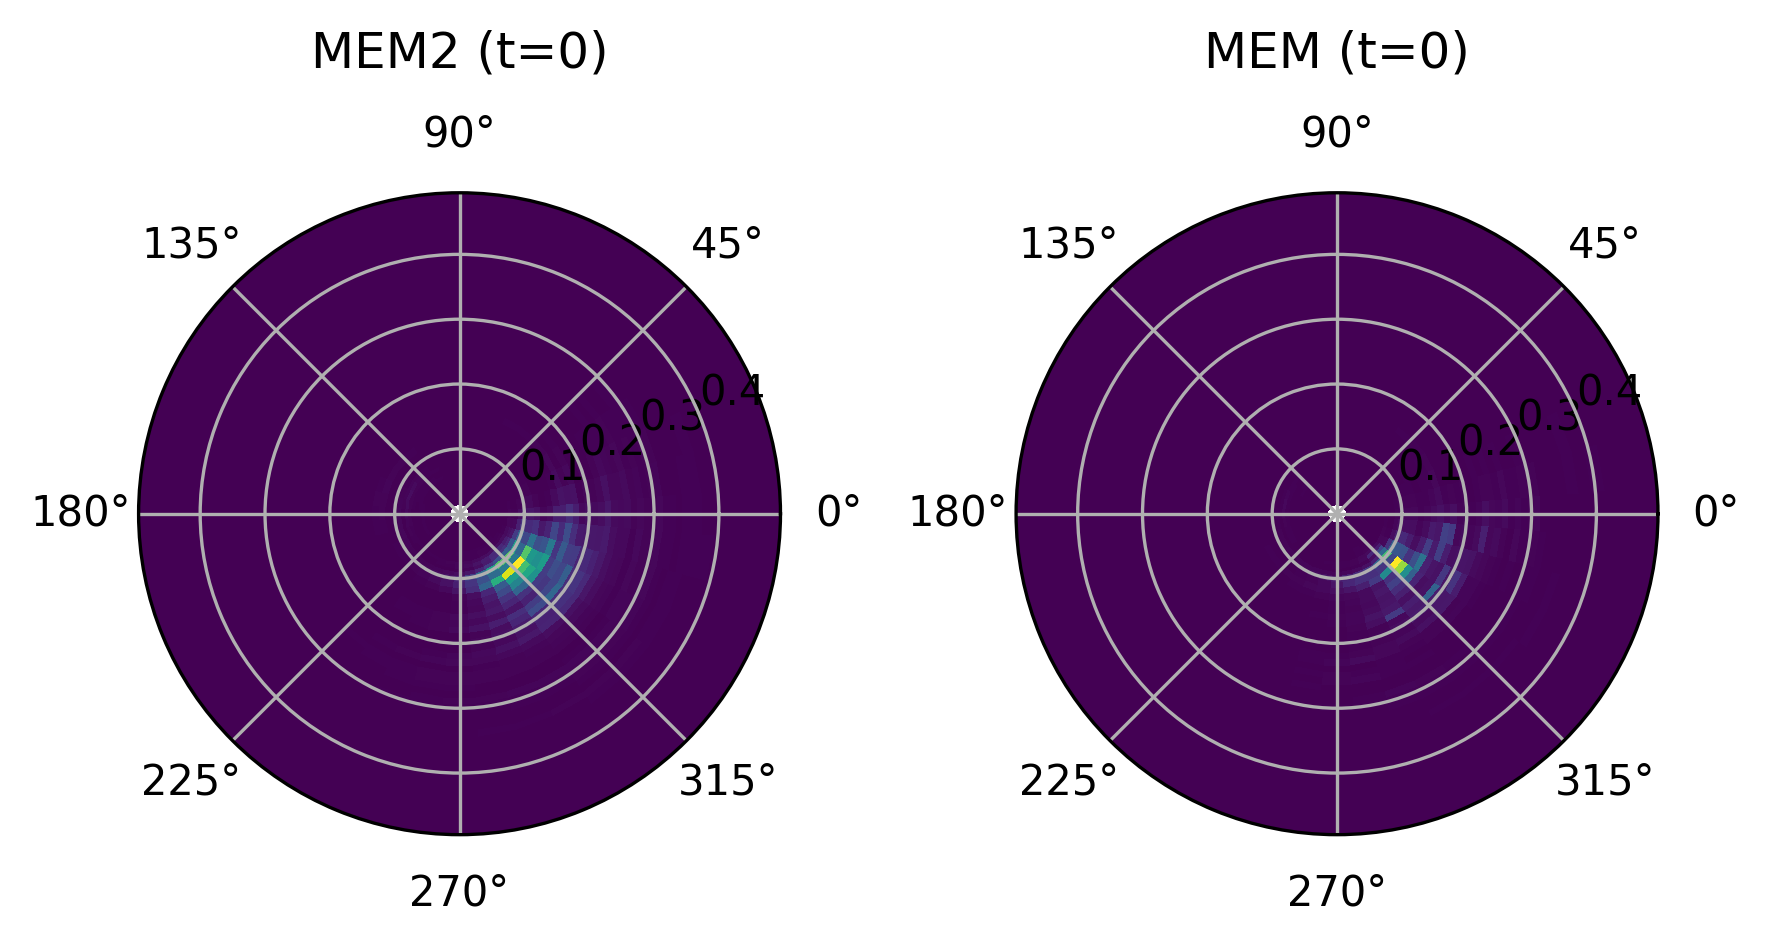

In [44]:
def plot_spec2d(ax, spec, title):
    E = spec.isel(time=0).directional_variance_density
    theta = np.deg2rad(E.direction.values)
    r = E.frequency.values
    T, R = np.meshgrid(theta, r)
    ax.pcolormesh(T, R, E.values)
    ax.set_title(title, pad=30)

fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(6, 4), dpi=300)
plot_spec2d(axes[0], spec2d, 'MEM2 (t=0)')
plot_spec2d(axes[1], spec2d_mem, 'MEM (t=0)')
plt.tight_layout()
plt.show()

In [29]:
import wavespectra

# Convert roguewavespectrum output to wavespectra format
# wavespectra requires: variable 'efth', dims named 'freq' and 'dir'
E = spec2d.directional_variance_density  # (time, frequency, direction)
ds_ws = xr.Dataset({'efth': E.rename({'frequency': 'freq', 'direction': 'dir'})})

# Partition into 3 parts using PTM3 (watershed algorithm, no wind/depth needed)
# Output shape: (part, time, freq, dir)
da_part = ds_ws.spec.partition.ptm3(parts=2)
stats = da_part.spec.stats(["hs", "tm01", "dm"]).compute()

In [31]:
# tm01 tends to have fewer nans than tp but still not entirely
print(np.isnan(stats.tm01.isel(part=0).values).sum())
print(np.isnan(stats.tm01.isel(part=1).values).sum())

0
3


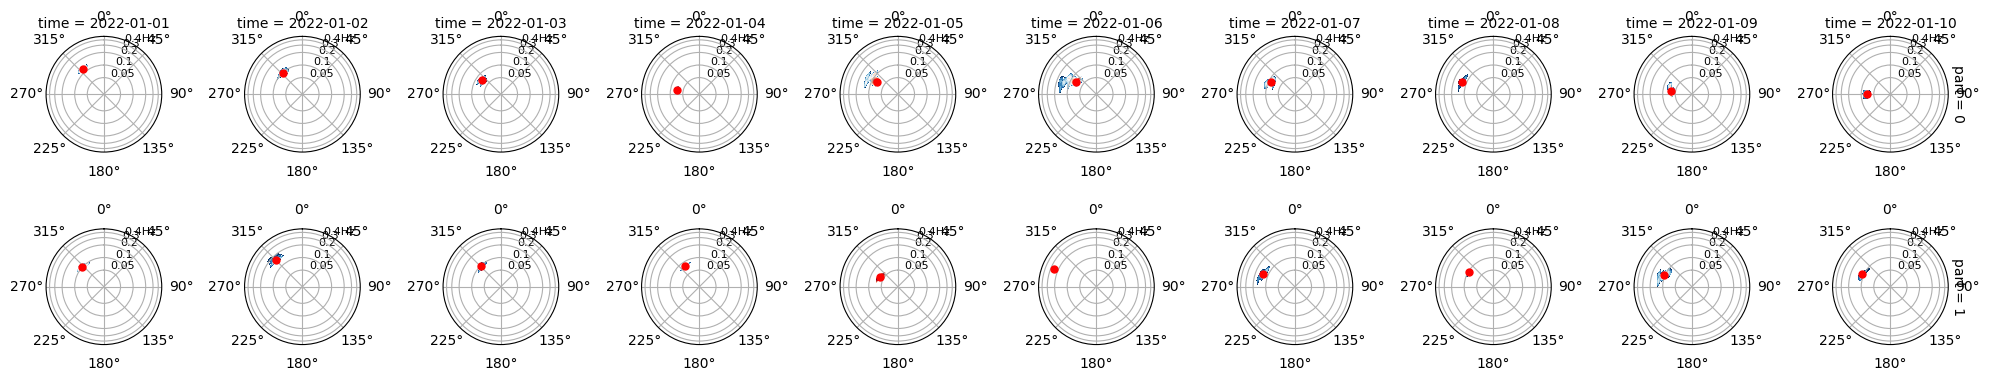

In [32]:
# Overlay mean frequency and direction on each panel as a red marker
# fg.axs shape: (n_parts, n_times)
fg = da_part.isel(time=slice(0, 80, 8), drop=True).spec.plot(
    clean_axis=False, row="part", col="time", figsize=(20, 4), add_colorbar=False
)

da_sub = da_part.isel(time=slice(0, 80, 8))  # same slice as the facet plot

# dm: mean direction (degrees), tp: peak period (s) -> mean_freq = 1/tp
stats = da_sub.spec.stats(["tp", "dm"]).compute()  # Dataset with dims (part, time)

for i_part in range(da_sub.sizes['part']):
    for i_time in range(da_sub.sizes['time']):
        ax = fg.axs[i_part, i_time]
        # NOTE: there is a 1000 factor when plotting
        # See https://github.com/wavespectra/wavespectra/blob/main/wavespectra/plot.py line 320
        mf = np.log10(float(1./stats.tp.isel(part=i_part, time=i_time))) + 3   
        md = np.deg2rad(float(stats.dm.isel(part=i_part, time=i_time)))
        ax.plot(md, mf, 'ro', markersize=5)

# for ax in fg.axes.flat:
#     ax.set_title("")
    
# for text in fg.row_labels:
#     text.set_text("")

plt.tight_layout()

### Check between modeled and buoy

In [39]:
dsp = xr.open_dataset('/pscratch/sd/j/jiarongw/wave_data/NDBC/ww3_buoy_partitioned_46042_2022.nc')
dsp = dsp.fillna(0)

Hs rmse: 0.587235, tp rmse: 2.57707, dm rmse: 28.1981


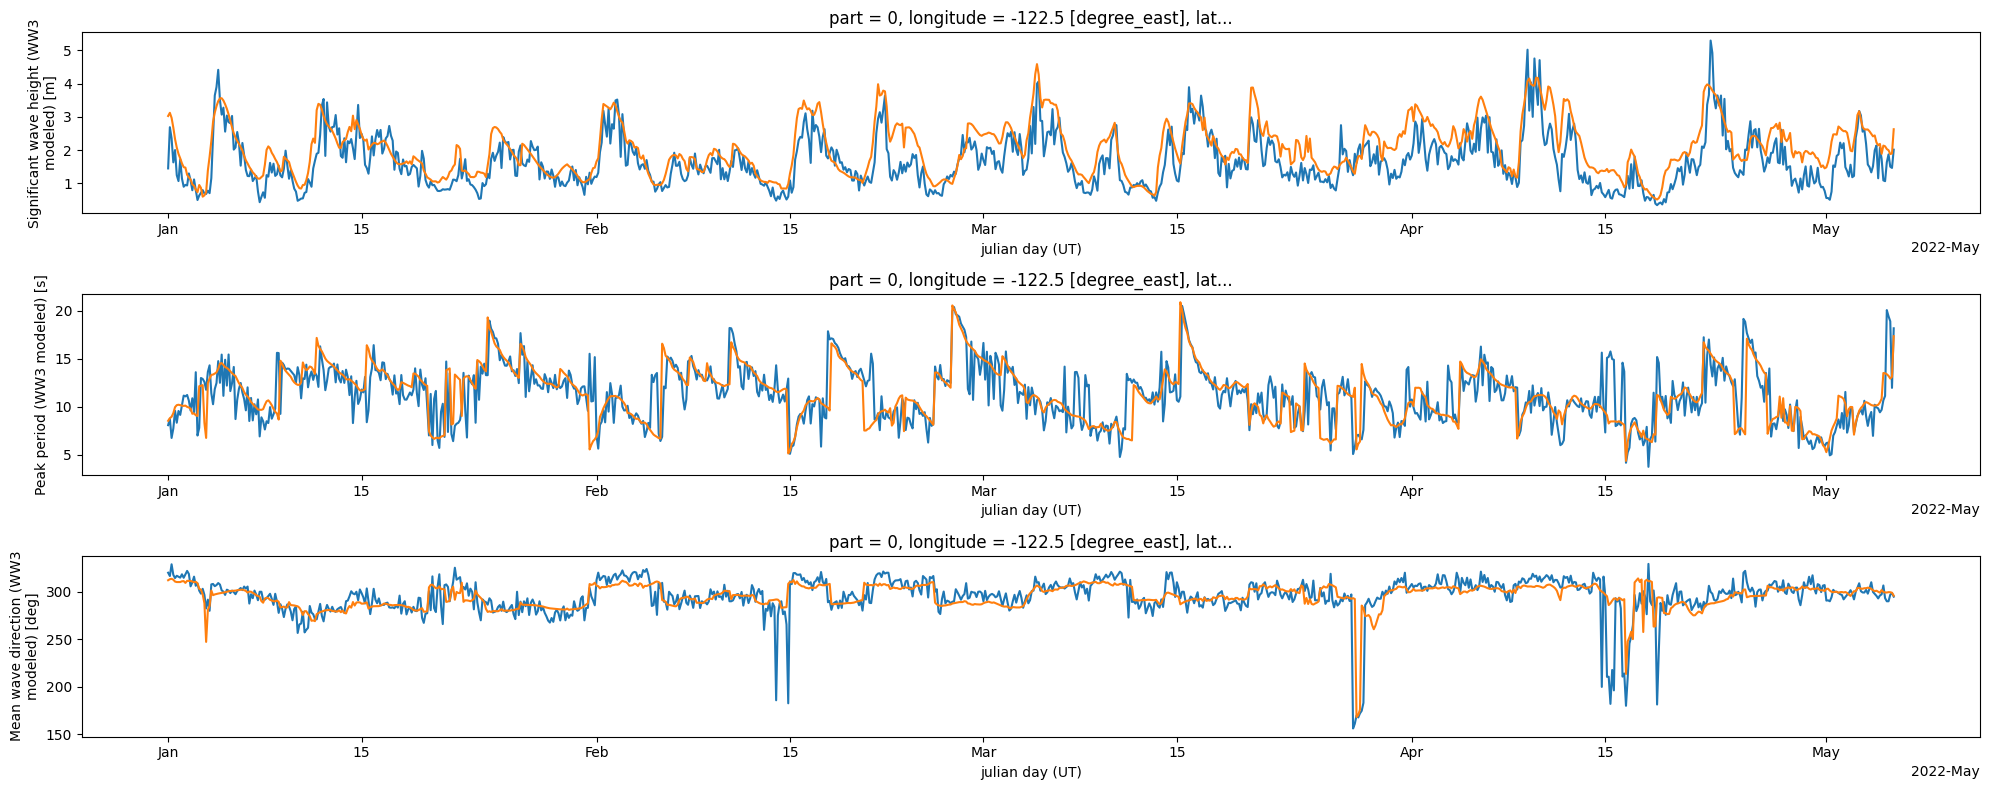

In [23]:
fig, axes = plt.subplots(3, 1, figsize=[20, 8])

p = 0
dsp.hs.isel(part=p, time=slice(0, 1000)).plot(ax=axes[0])
dsp.hs_m.isel(part=p, time=slice(0, 1000)).plot(ax=axes[0])
dsp.tp.isel(part=p, time=slice(0, 1000)).plot(ax=axes[1])
dsp.tp_m.isel(part=p, time=slice(0, 1000)).plot(ax=axes[1])
dsp.dm.isel(part=p, time=slice(0, 1000)).plot(ax=axes[2])
dsp.dm_m.isel(part=p, time=slice(0, 1000)).plot(ax=axes[2])
plt.tight_layout()

rmse1 = np.mean((dsp.hs_m.isel(part=p).values - dsp.hs.isel(part=p).values) ** 2) ** 0.5
rmse2 = np.mean((dsp.tp_m.isel(part=p).values - dsp.tp.isel(part=p).values) ** 2) ** 0.5
rmse3 = np.mean((dsp.dm_m.isel(part=p).values - dsp.dm.isel(part=p).values) ** 2) ** 0.5
print('Hs rmse: %g, tp rmse: %g, dm rmse: %g' %(rmse1, rmse2, rmse3))

Hs rmse: 0.536342, tp rmse: 6.32715, dm rmse: 91.9296


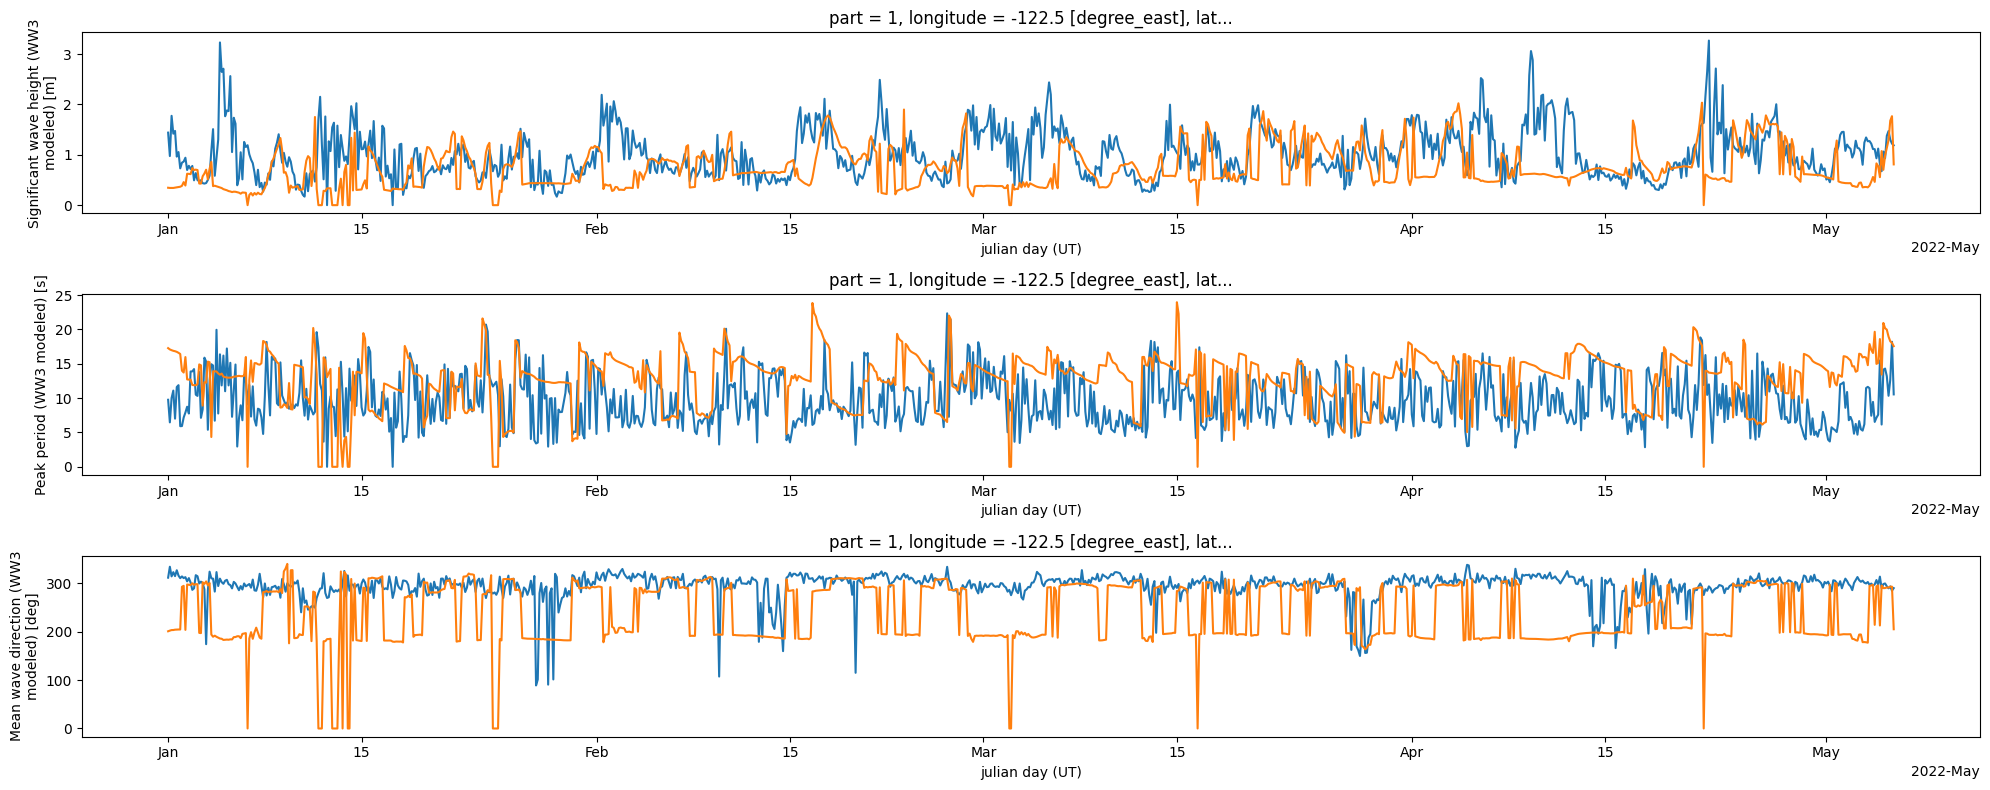

In [40]:
fig, axes = plt.subplots(3, 1, figsize=[20, 8])

p = 1
dsp.hs.isel(part=p, time=slice(0, 1000)).plot(ax=axes[0])
dsp.hs_m.isel(part=p, time=slice(0, 1000)).plot(ax=axes[0])
dsp.tp.isel(part=p, time=slice(0, 1000)).plot(ax=axes[1])
dsp.tp_m.isel(part=p, time=slice(0, 1000)).plot(ax=axes[1])
dsp.dm.isel(part=p, time=slice(0, 1000)).plot(ax=axes[2])
dsp.dm_m.isel(part=p, time=slice(0, 1000)).plot(ax=axes[2])
plt.tight_layout()

rmse1 = np.mean((dsp.hs_m.isel(part=p).values - dsp.hs.isel(part=p).values) ** 2) ** 0.5
rmse2 = np.mean((dsp.tp_m.isel(part=p).values - dsp.tp.isel(part=p).values) ** 2) ** 0.5
rmse3 = np.mean((dsp.dm_m.isel(part=p).values - dsp.dm.isel(part=p).values) ** 2) ** 0.5
print('Hs rmse: %g, tp rmse: %g, dm rmse: %g' %(rmse1, rmse2, rmse3))

In [15]:
np.where(np.isnan(ds_part.tp.isel(part=1).values))[0]

array([  92,  130, 2630])

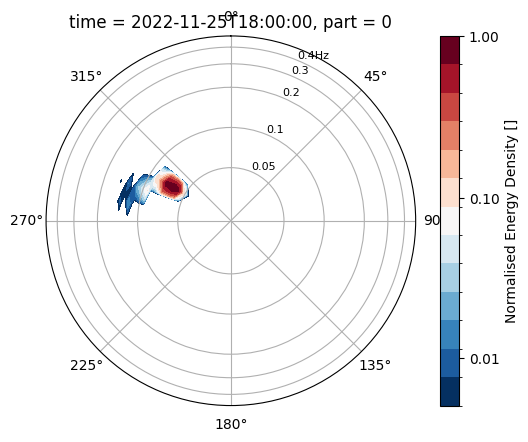

In [38]:
da_part.isel(time=2630, part=0).spec.plot()

In [ ]:
def plot_spec2d(ax, spec, title):
    E = spec.isel(time=0).directional_variance_density
    theta = np.deg2rad(E.direction.values)
    r = E.frequency.values
    T, R = np.meshgrid(theta, r)
    ax.pcolormesh(T, R, E.values)
    ax.set_title(title, pad=30)

fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(6, 4), dpi=300)
plot_spec2d(axes[0], spec2d, 'MEM2 (t=0)')
plot_spec2d(axes[1], spec2d_mem, 'MEM (t=0)')
plt.tight_layout()
plt.show()